In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.mixture import GaussianMixture

In [ ]:
X, y = load_wine(return_X_y=True)
X = StandardScaler().fit_transform(X)

n, d = X.shape
print("Shape:", X.shape)

Shape: (178, 13)


In [ ]:
X, y = load_wine(return_X_y=True)
X = StandardScaler().fit_transform(X)

n, d = X.shape
print("Shape:", X.shape)

Shape: (178, 13)


In [ ]:
def logsumexp(a, axis=None, keepdims=False):
    a_max = np.max(a, axis=axis, keepdims=True)
    out = a_max + np.log(np.sum(np.exp(a - a_max), axis=axis, keepdims=True))
    if not keepdims:
        out = np.squeeze(out, axis=axis)
    return out

In [ ]:
def log_gaussian_diag(X, mu, var):
    d = X.shape[1]
    eps = 1e-12
    var = np.maximum(var, eps)
    diff = X - mu
    return -0.5 * (d * np.log(2*np.pi) + np.sum(np.log(var)) + np.sum(diff*diff / var, axis=1))

In [ ]:
def init_means_kpp(X, k, random_state=0):
    rng = np.random.default_rng(random_state)
    n = X.shape[0]
    means = []

    first = rng.integers(0, n)
    means.append(X[first].copy())

    closest = np.sum((X - means[0])**2, axis=1)

    for _ in range(1, k):
        probs = closest / np.sum(closest)
        idx = rng.choice(n, p=probs)
        means.append(X[idx].copy())
        newd = np.sum((X - means[-1])**2, axis=1)
        closest = np.minimum(closest, newd)

    return np.array(means)

## Expectation maximization

In [ ]:
def gmm_em_diag(X, k, max_iter=200, tol=1e-4, random_state=0, return_history=True):
    rng = np.random.default_rng(random_state)
    n, d = X.shape

    # init
    mu = init_means_kpp(X, k, random_state=random_state)          # (k,d)
    var = np.ones((k, d))                                         # (k,d) diagonal variances
    pi = np.ones(k) / k                                           # (k,)

    history = {"loglik": []}

    for _ in range(max_iter):
        # E-step: log responsibilities
        log_prob = np.zeros((n, k))
        for j in range(k):
            log_prob[:, j] = np.log(pi[j]) + log_gaussian_diag(X, mu[j], var[j])

        log_norm = logsumexp(log_prob, axis=1, keepdims=True)     # (n,1)
        log_gamma = log_prob - log_norm                           # (n,k)
        gamma = np.exp(log_gamma)                                 # (n,k)

        loglik = float(np.sum(log_norm))
        if return_history:
            history["loglik"].append(loglik)

        # M-step
        Nk = np.sum(gamma, axis=0)                                 # (k,)
        pi = Nk / n                                                # (k,)
        mu = (gamma.T @ X) / Nk[:, None]                           # (k,d)

        # diagonal variance
        for j in range(k):
            diff = X - mu[j]
            var[j] = (gamma[:, j][:, None] * (diff * diff)).sum(axis=0) / Nk[j]

        # convergence check
        if len(history["loglik"]) > 1:
            if abs(history["loglik"][-1] - history["loglik"][-2]) < tol:
                break

    # final responsibilities + labels
    log_prob = np.zeros((n, k))
    for j in range(k):
        log_prob[:, j] = np.log(pi[j]) + log_gaussian_diag(X, mu[j], var[j])
    log_norm = logsumexp(log_prob, axis=1, keepdims=True)
    gamma = np.exp(log_prob - log_norm)
    labels = np.argmax(gamma, axis=1)

    return {
        "pi": pi,
        "mu": mu,
        "var": var,
        "gamma": gamma,
        "labels": labels,
        "loglik": float(np.sum(log_norm)),
        "n_iter": len(history["loglik"]),
        "history": history if return_history else None
    }

In [ ]:
k = 3

res = gmm_em_diag(X, k=k, max_iter=300, tol=1e-5, random_state=7)

print("GMM-EM (diag, from scratch)")
print("  Iteraciones:", res["n_iter"])
print("  Log-likelihood:", round(res["loglik"], 4))
print("  pi:", np.round(res["pi"], 4))

GMM-EM (diag, from scratch)
  Iteraciones: 47
  Log-likelihood: -2582.3481
  pi: [0.3109 0.2976 0.3915]


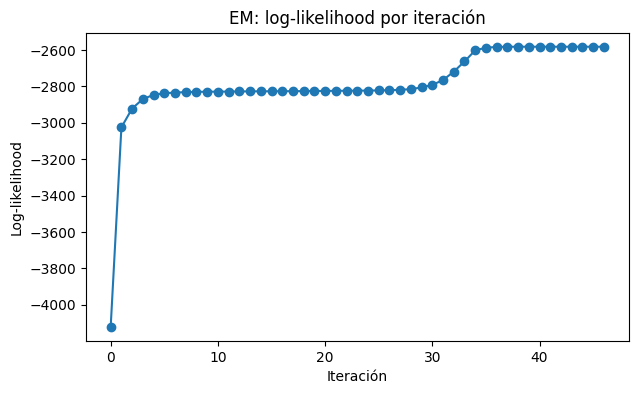

In [ ]:
plt.figure(figsize=(7,4))
plt.plot(res["history"]["loglik"], marker="o")
plt.title("EM: log-likelihood por iteración")
plt.xlabel("Iteración")
plt.ylabel("Log-likelihood")
plt.show()

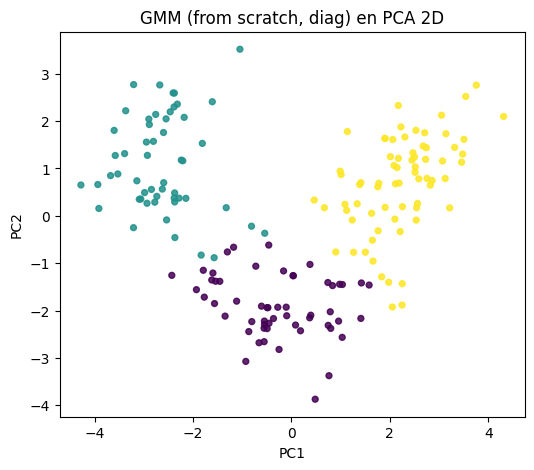

In [ ]:
X2 = PCA(n_components=2, random_state=0).fit_transform(X)

plt.figure(figsize=(6,5))
plt.scatter(X2[:,0], X2[:,1], c=res["labels"], s=18, alpha=0.85)
plt.title("GMM (from scratch, diag) en PCA 2D")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

# AIC/BIC

In [ ]:
def aic_bic_from_loglik(loglik, n, p):
    aic = 2*p - 2*loglik
    bic = p*np.log(n) - 2*loglik
    return float(aic), float(bic)

def num_params_gmm_diag(k, d):
    return (k - 1) + 2*k*d

p = num_params_gmm_diag(k, d)
aic, bic = aic_bic_from_loglik(res["loglik"], n=n, p=p)

print("Params (diag):", p)
print("AIC:", round(aic, 4))
print("BIC:", round(bic, 4))

Params (diag): 80
AIC: 5324.6961
BIC: 5579.2388


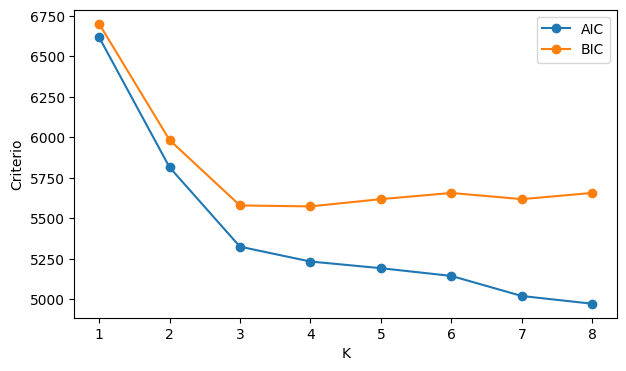

Mejor K por AIC: 8
Mejor K por BIC: 4


In [ ]:
Ks = list(range(1, 9))
out = []

for kk in Ks:
    r = gmm_em_diag(X, k=kk, max_iter=300, tol=1e-5, random_state=7)
    p = num_params_gmm_diag(kk, d)
    aic, bic = aic_bic_from_loglik(r["loglik"], n=n, p=p)
    out.append((kk, r["loglik"], aic, bic))

out = np.array(out, dtype=float)

plt.figure(figsize=(7,4))
plt.plot(out[:,0], out[:,2], marker="o", label="AIC")
plt.plot(out[:,0], out[:,3], marker="o", label="BIC")
plt.xlabel("K")
plt.ylabel("Criterio")
plt.legend()
plt.show()

print("Mejor K por AIC:", int(out[np.argmin(out[:,2]), 0]))
print("Mejor K por BIC:", int(out[np.argmin(out[:,3]), 0]))

## Skelearn

In [ ]:
def plot_gmm_density_2d(X2, gmm, title):
    x_min, x_max = X2[:, 0].min() - 1.0, X2[:, 0].max() + 1.0
    y_min, y_max = X2[:, 1].min() - 1.0, X2[:, 1].max() + 1.0
    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 300),
        np.linspace(y_min, y_max, 300)
    )
    grid = np.c_[xx.ravel(), yy.ravel()]

    # log p(x) en el grid (2D) y densidad p(x)
    logp = gmm.score_samples(grid)
    Z = np.exp(logp).reshape(xx.shape)

    labels = gmm.predict(X2)

    plt.figure(figsize=(6, 5))
    plt.contourf(xx, yy, Z, levels=40, alpha=0.65)
    plt.scatter(X2[:, 0], X2[:, 1], c=labels, s=18, alpha=0.9)
    plt.title(title)
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.show()

In [ ]:
gmm2_diag = GaussianMixture(
    n_components=3,
    covariance_type="diag",
    n_init=10,
    random_state=7
).fit(X2)

gmm2_full = GaussianMixture(
    n_components=3,
    covariance_type="full",
    n_init=10,
    random_state=7
).fit(X2)

print("diag  AIC:", round(float(gmm2_diag.aic(X2)), 4), " BIC:", round(float(gmm2_diag.bic(X2)), 4))
print("full  AIC:", round(float(gmm2_full.aic(X2)), 4), " BIC:", round(float(gmm2_full.bic(X2)), 4))



diag  AIC: 1274.8584  BIC: 1319.4034
full  AIC: 1259.2852  BIC: 1313.3755


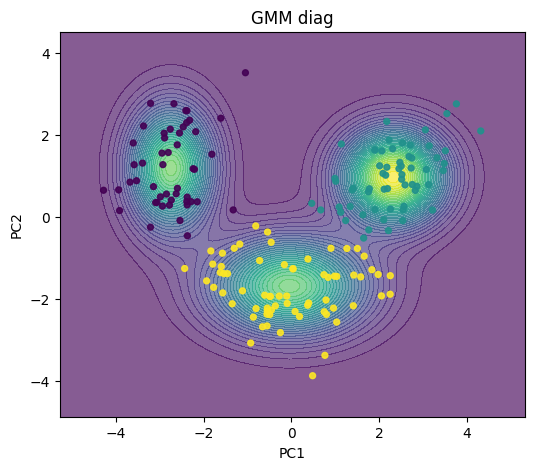

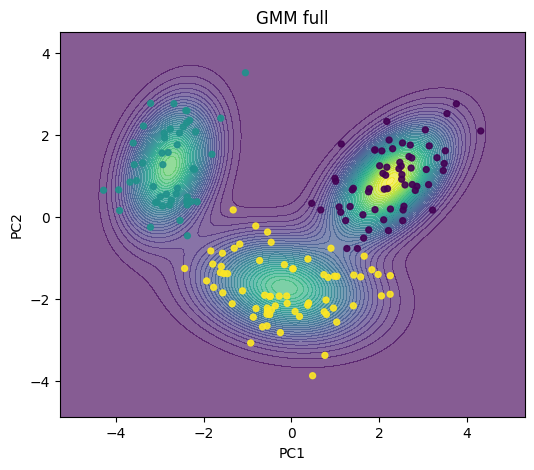

In [ ]:
plot_gmm_density_2d(X2, gmm2_diag, "GMM diag")
plot_gmm_density_2d(X2, gmm2_full, "GMM full")